# ECG5000 using MILLET (simple notes)

This notebook is a full run from data loading to interpretation.

Main goal in this notebook: show how MILLET interpretation works on ECG5000.
Improving minority-class accuracy is important, but not the main objective of this notebook.

In [2]:
# CELL 1: Setup
import os
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from matplotlib import pyplot as plt
import seaborn as sns
from collections import Counter
from texttable import Texttable


# Need to keep scienceplots imported for matplotlib styling even though the import is never used directly
# noinspection PyUnresolvedReferences
import scienceplots
%load_ext autoreload
%autoreload 2

if os.getcwd().endswith("notebooks"):
    os.chdir("../")

torch.manual_seed(42)
np.random.seed(42)

plt.style.use(["science", "bright", "no-latex", "grid"])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# CELL 2: Load dataset
from millet.data.ecg5000_dataset import ECG5000Dataset

train_dataset = ECG5000Dataset("TRAIN")
test_dataset = ECG5000Dataset("TEST")

ECG5000_CLASS_NAMES = ["Normal", "R-on-T PVC", "PVC", "SP", "UB"]

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)} | Classes: {train_dataset.n_clz}")

📂 Loaded 500 rows from data/ECG5000/ECG5000_TRAIN.ts
✅ Processed 500 valid samples

ECG5000 TRAIN Split - Class Distribution
Total samples: 500
Classes: 5
----------------------------------------
Class 0 (Normal      ):  292 ( 58.4%) weight=0.342 |█████████████████████████████░░░░░░░░░░░░░░░░░░░░░|
Class 1 (R-on-T PVC  ):  177 ( 35.4%) weight=0.565 |█████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
Class 2 (PVC         ):   10 (  2.0%) weight=10.000 |█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
Class 3 (SP          ):   19 (  3.8%) weight=5.263 |█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
Class 4 (UB          ):    2 (  0.4%) weight=50.000 |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|

📂 Loaded 4500 rows from data/ECG5000/ECG5000_TEST.ts
✅ Processed 4500 valid samples

ECG5000 TEST Split - Class Distribution
Total samples: 4500
Classes: 5
----------------------------------------
Class 0 (Normal      ): 2627 ( 58.4%) weight=0.343 |█████████████████████████████░░░

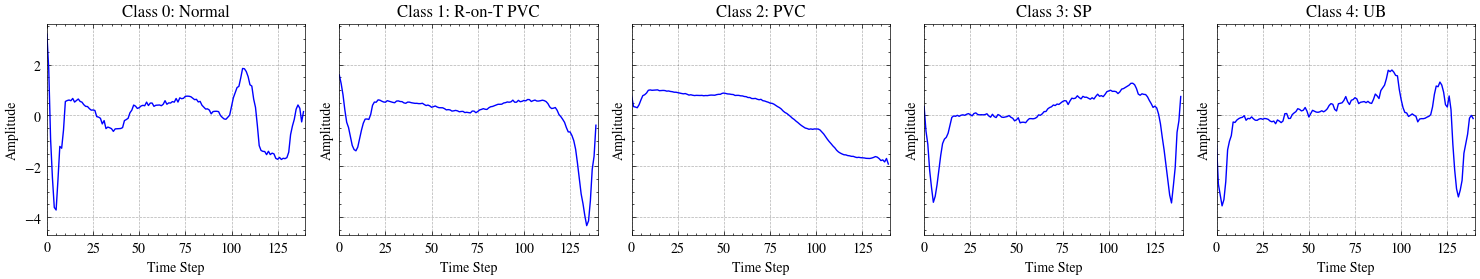

In [4]:
# CELL 3: Plot one example per class
def plot_class_examples(dataset, class_names):
    fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
    for c in range(dataset.n_clz):
        idxs = dataset.get_samples_by_class(c, n_samples=1)
        ts = dataset.get_bag(idxs[0]).squeeze().numpy()
        axes[c].plot(ts, 'b-', linewidth=1)
        axes[c].set_title(f"Class {c}: {class_names[c]}")
        axes[c].set_xlabel("Time Step")
        axes[c].set_ylabel("Amplitude")
        axes[c].set_xlim(0, len(ts))
        axes[c].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_class_examples(train_dataset, ECG5000_CLASS_NAMES)

### Quick note after class examples

Each class has a different ECG shape pattern.
This gives a first idea that model can learn class-specific morphology.

Small conclusion: waveform shape is class dependent, so feature extraction should help.

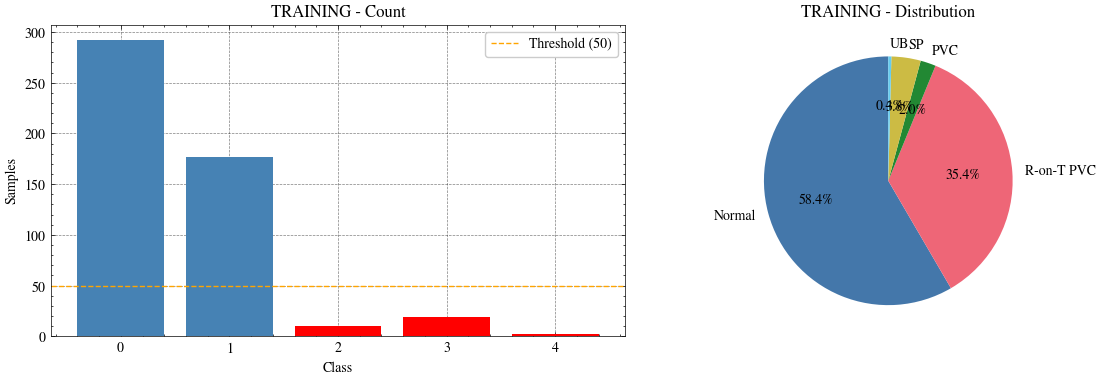

  Class 0:  292 samples - OK
  Class 1:  177 samples - OK
  Class 2:   10 samples - MINORITY
  Class 3:   19 samples - MINORITY
  Class 4:    2 samples - MINORITY


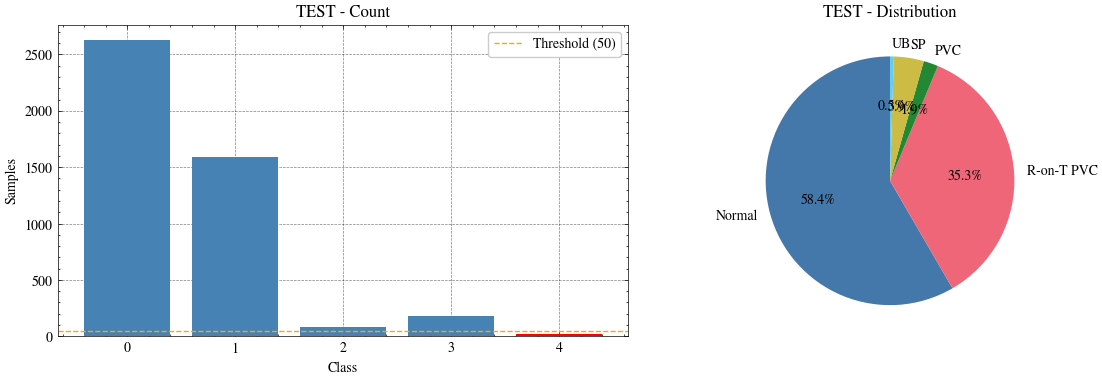

  Class 0: 2627 samples - OK
  Class 1: 1590 samples - OK
  Class 2:   86 samples - OK
  Class 3:  175 samples - OK
  Class 4:   22 samples - MINORITY


In [5]:
# CELL 4: Analyze class distribution
def show_distribution(dataset, class_names, title):
    counts = dataset.class_counts
    classes = list(range(dataset.n_clz))
    counts_list = [counts.get(c, 0) for c in classes]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = ['red' if c < 50 else 'steelblue' for c in counts_list]
    axes[0].bar(classes, counts_list, color=colors)
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Samples")
    axes[0].set_title(f"{title} - Count")
    axes[0].axhline(y=50, color='orange', linestyle='--', label='Threshold (50)')
    axes[0].legend()
    
    axes[1].pie(counts_list, labels=class_names, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f"{title} - Distribution")
    plt.tight_layout()
    plt.show()
    
    for c, count in enumerate(counts_list):
        status = "MINORITY" if count < 50 else "OK"
        print(f"  Class {c}: {count:4d} samples - {status}")

show_distribution(train_dataset, ECG5000_CLASS_NAMES, "TRAINING")
show_distribution(test_dataset, ECG5000_CLASS_NAMES, "TEST")

### Quick note after distribution plots

The dataset is strongly imbalanced.
PVC, SP and especially UB have much fewer samples than Normal and R-on-T PVC.

Small conclusion: imbalance is a major reason for low minority performance.

In [6]:
# CELL 5: Simple data augmentation class
class SimpleAugmenter:
    def __init__(self, noise_std=0.01, scale_range=(0.95, 1.05), seed=42):
        np.random.seed(seed)
        self.noise_std = noise_std
        self.scale_range = scale_range
    
    def augment(self, x):
        aug = x.clone()
        if np.random.random() < 0.5:
            aug = aug + torch.randn_like(aug) * self.noise_std
        if np.random.random() < 0.5:
            aug = aug * np.random.uniform(*self.scale_range)
        return aug

augmenter = SimpleAugmenter()

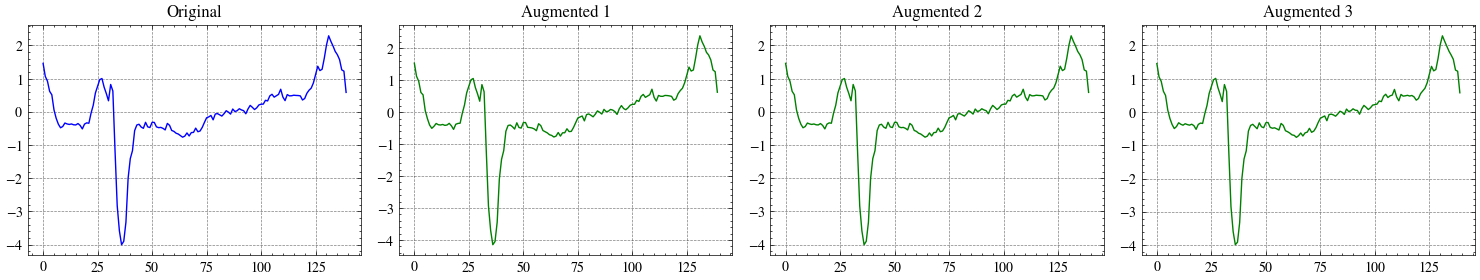

In [7]:
# CELL 6: Visualize augmentation
idx = train_dataset.get_samples_by_class(2, n_samples=1)[0]
original = train_dataset.get_bag(idx).squeeze().numpy()

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes[0].plot(original, 'b-')
axes[0].set_title("Original")
for i in range(1, 4):
    aug = augmenter.augment(torch.as_tensor(original).unsqueeze(1)).squeeze().numpy()
    axes[i].plot(aug, 'g-')
    axes[i].set_title(f"Augmented {i}")
plt.tight_layout()
plt.show()

In [8]:
# CELL 7: Create balanced dataset
class BalancedDataset:
    def __init__(self, base_dataset, augmenter, target_per_class=250):
        self.base = base_dataset
        self.n_clz = base_dataset.n_clz
        self.samples = {c: [] for c in range(self.n_clz)}
        self.targets = {c: [] for c in range(self.n_clz)}
        
        for idx in range(len(base_dataset)):
            s = base_dataset.get_bag(idx)
            t = base_dataset.targets[idx].item()
            self.samples[t].append(s)
            self.targets[t].append(t)
        
        print("Augmenting minority classes:")
        for c in range(self.n_clz):
            current = len(self.samples[c])
            needed = max(0, target_per_class - current)
            if needed > 0:
                print(f"  Class {c}: {current} -> +{needed} augmented")
                for _ in range(needed):
                    orig = self.samples[c][np.random.randint(current)]
                    self.samples[c].append(augmenter.augment(orig))
                    self.targets[c].append(c)
        
        self.all_samples = []
        self.all_targets = []
        for c in range(self.n_clz):
            self.all_samples.extend(self.samples[c])
            self.all_targets.extend(self.targets[c])
        
        idxs = np.random.permutation(len(self.all_samples))
        self.all_samples = [self.all_samples[i] for i in idxs]
        self.all_targets = torch.tensor([self.all_targets[i] for i in idxs])
        print(f"Total: {len(self.all_samples)} samples")
    
    def __len__(self):
        return len(self.all_samples)
    
    def __getitem__(self, idx):
        return {"bag": self.all_samples[idx], "target": self.all_targets[idx]}

balanced_train = BalancedDataset(train_dataset, augmenter, target_per_class=250)

Augmenting minority classes:
  Class 1: 177 -> +73 augmented
  Class 2: 10 -> +240 augmented
  Class 3: 19 -> +231 augmented
  Class 4: 2 -> +248 augmented
Total: 1292 samples


In [9]:
# CELL 8: Build model
from millet.model import backbone, pooling
from millet.model.millet_model import MILLETModel
from millet.util import get_gpu_device_for_os

device = get_gpu_device_for_os()
print(f"Device: {device}")

class_weights = train_dataset.get_class_weights().to(device)

net = nn.Sequential(
    backbone.InceptionTimeFeatureExtractor(1),
    pooling.MILConjunctivePooling(128, train_dataset.n_clz, dropout=0.2, apply_positional_encoding=True)
)

class WeightedModel(MILLETModel):
    def __init__(self, name, device, n_clz, net, class_weights):
        super().__init__(name, device, n_clz, net)
        self.class_weights = class_weights
    
    def compute_loss(self, model_out):
        return nn.CrossEntropyLoss(weight=self.class_weights)(
            model_out["bag_logits"], model_out["targets"])

model = WeightedModel("ECG5000", device, train_dataset.n_clz, net, class_weights)

Device: cuda


Training: 100%|██████████| 300/300 [19:44<00:00,  3.95s/it, loss=0.0000]


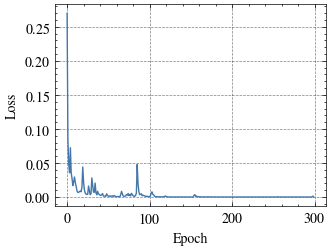

[0.2699520251736408,
 0.08383281011043525,
 0.048015470775525745,
 0.0354889776194241,
 0.07243358550547827,
 0.035228373437393004,
 0.02725921264599736,
 0.016784037020420882,
 0.022013926287976708,
 0.029384078457951546,
 0.02106668962529156,
 0.015786136438070638,
 0.008858890633280502,
 0.006750847056803361,
 0.006627001332562053,
 0.008281596428033238,
 0.008511951985405532,
 0.007731130525537926,
 0.014613610800219381,
 0.044097727846081666,
 0.021491950553864603,
 0.01021482215387883,
 0.005939673558558996,
 0.004178650792909604,
 0.0037985553655478102,
 0.004056877125815556,
 0.01616717109076179,
 0.00998325311726459,
 0.003419789204532962,
 0.0045875552140187655,
 0.02804522609292734,
 0.018120009917765856,
 0.007488486328639272,
 0.006802116776248667,
 0.020503335138328554,
 0.006101412468635273,
 0.0032317429822131356,
 0.00846554226349903,
 0.004518654525404933,
 0.0040378344945166626,
 0.0024708129530176294,
 0.0023752885023075178,
 0.003514900538437182,
 0.005077565867573

In [11]:
# CELL 9: Train (FIXED)
from tqdm import tqdm

def train_model(model, dataset, epochs=300, batch_size=32, lr=1e-3):
    targets = dataset.all_targets.numpy()
    class_counts = np.bincount(targets)
    weights = 1.0 / class_counts[targets]
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)
    loader = DataLoader(dataset, batch_size=batch_size, sampler=sampler)
    
    optimizer = torch.optim.Adam(model.net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    
    losses = []
    bar = tqdm(range(epochs), desc="Training")
    for epoch in bar:
        epoch_loss = 0
        for batch in loader:
            bags = batch["bag"].to(device)
            targets = batch["target"].to(device)
            
            # FIX: Reshape from (batch, timesteps) to (batch, channels, timesteps)
            bags = bags.permute(0, 2, 1) if bags.dim() == 3 else bags.unsqueeze(1)
            
            optimizer.zero_grad()
            out = model.net(bags)
            out["targets"] = targets
            loss = model.compute_loss(out)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(loader))
        scheduler.step()
        bar.set_postfix({"loss": f"{losses[-1]:.4f}"})
    
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()
    return losses

train_model(model, balanced_train, epochs=300)

In [12]:
# CELL 10: Save model
os.makedirs("model/ECG5000", exist_ok=True)
model.save_weights("model/ECG5000/Balanced_ECG5000.pth")

Saving model to model/ECG5000/Balanced_ECG5000.pth


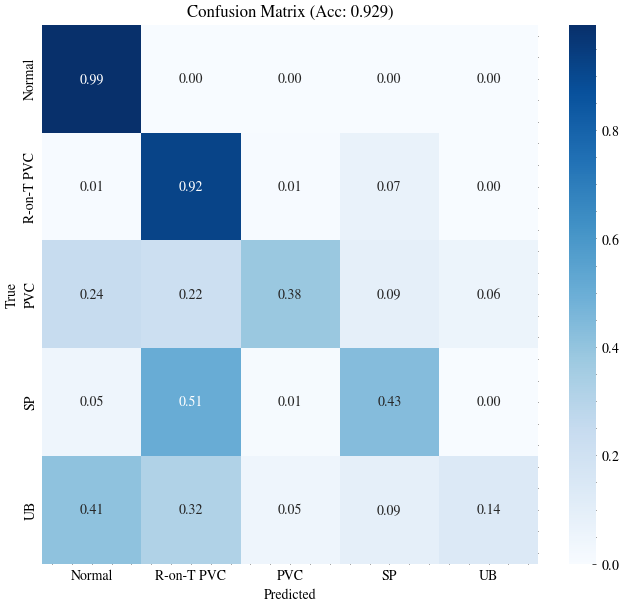

Normal         : 0.994
R-on-T PVC     : 0.916
PVC            : 0.384
SP             : 0.434
UB             : 0.136


In [16]:
# CELL 11: Evaluate (FIXED)
from sklearn.metrics import confusion_matrix

model.net.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for idx in range(len(test_dataset)):
        bag = test_dataset.get_bag(idx).to(device)
        target = test_dataset.targets[idx].item()
        
        # FIX: Reshape correctly for model input
        # Original shape: (timesteps, channels) -> need (1, channels, timesteps)
        if bag.dim() == 2:
            bag_input = bag.permute(1, 0).unsqueeze(0)
        else:
            bag_input = bag.unsqueeze(0)
        
        out = model.net(bag_input)
        pred = torch.argmax(out["bag_logits"]).item()
        all_preds.append(pred)
        all_targets.append(target)

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
acc = np.mean(all_preds == all_targets)

conf_mat = confusion_matrix(all_targets, all_preds)
conf_mat_norm = conf_mat.astype('float') / conf_mat.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(conf_mat_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=ECG5000_CLASS_NAMES, yticklabels=ECG5000_CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix (Acc: {acc:.3f})")
plt.show()

for c, name in enumerate(ECG5000_CLASS_NAMES):
    mask = all_targets == c
    if mask.sum() > 0:
        print(f"{name:15s}: {np.mean(all_preds[mask]==c):.3f}")

### Quick note after confusion matrix

Overall accuracy is good, but minority classes are weak.
From this run, Normal and R-on-T PVC are high, while PVC/SP/UB are low.

Small conclusion: class imbalance + class overlap affects minority recall.

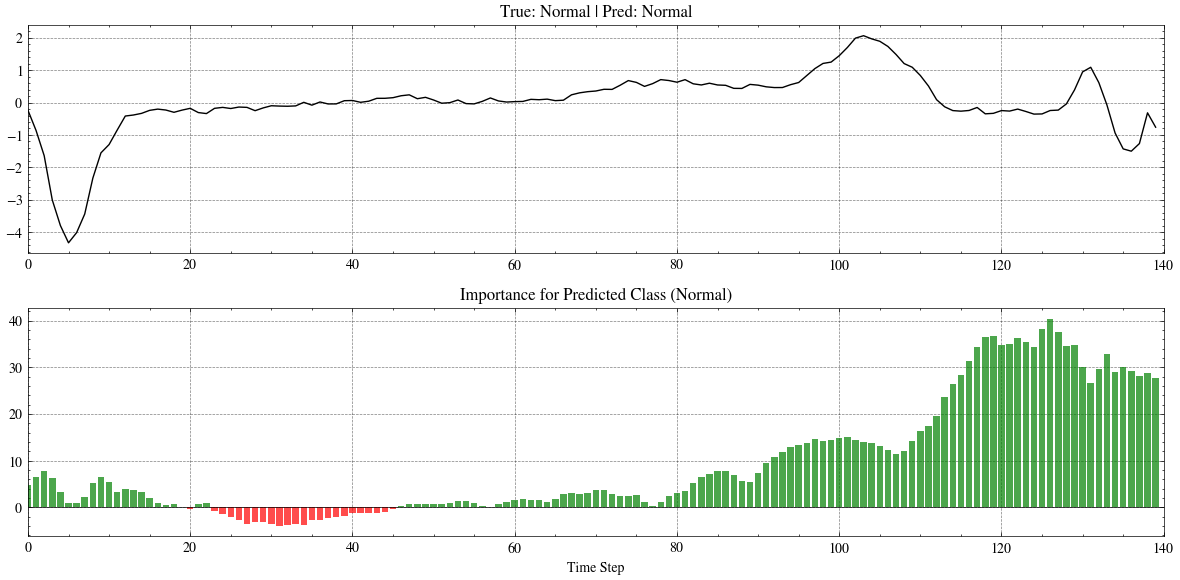

In [17]:
# CELL 12: Simple interpretation for one sample (FIXED)
def interpret_sample(model, dataset, idx, class_names):
    bag = dataset.get_bag(idx).to(device)
    true = dataset.targets[idx].item()
    
    # FIX: Reshape correctly
    if bag.dim() == 2:
        bag_input = bag.permute(1, 0).unsqueeze(0)
    else:
        bag_input = bag.unsqueeze(0)
    
    with torch.no_grad():
        out = model.net(bag_input)
        pred = torch.argmax(out["bag_logits"]).item()
        interp = model.interpret(out).squeeze().cpu().numpy()
    
    bag_np = bag.squeeze().cpu().numpy()
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    
    axes[0].plot(bag_np, 'k-', linewidth=1)
    axes[0].set_title(f"True: {class_names[true]} | Pred: {class_names[pred]}")
    axes[0].set_xlim(0, len(bag_np))
    
    x = np.arange(len(bag_np))
    colors = ['red' if v < 0 else 'green' for v in interp[pred]]
    axes[1].bar(x, interp[pred], color=colors, alpha=0.7)
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].set_title(f"Importance for Predicted Class ({class_names[pred]})")
    axes[1].set_xlim(0, len(bag_np))
    axes[1].set_xlabel("Time Step")
    
    plt.tight_layout()
    plt.show()

idx = test_dataset.get_samples_by_class(0, n_samples=1)[0]
interpret_sample(model, test_dataset, idx, ECG5000_CLASS_NAMES)

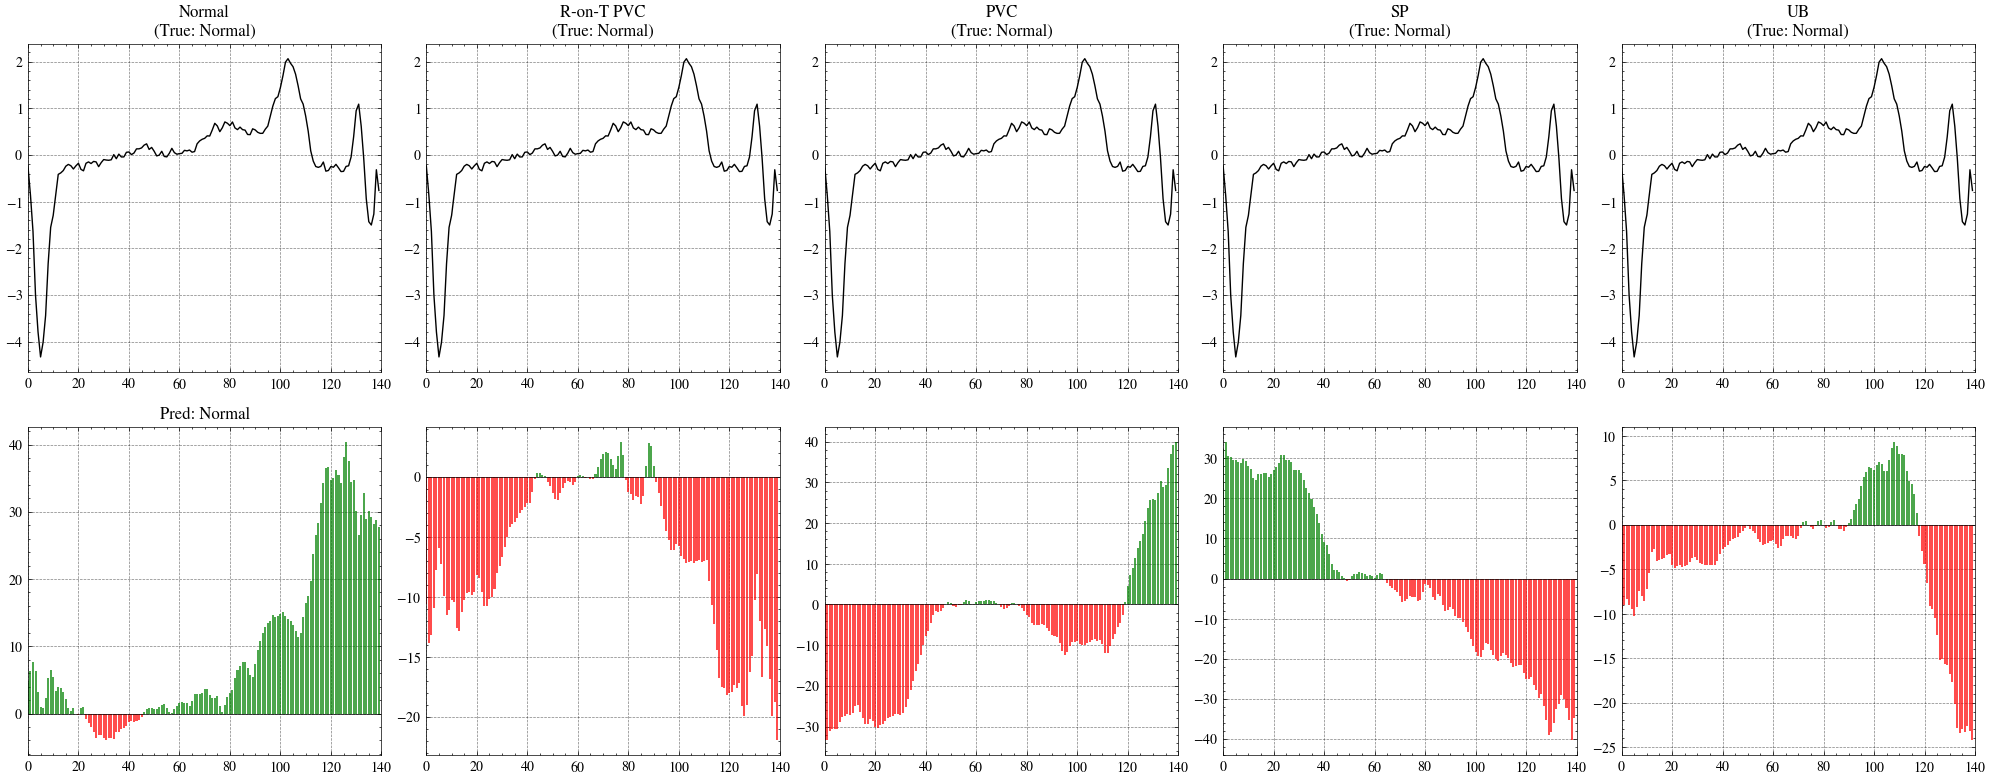

In [18]:
# CELL 13: Compare interpretation across classes (FIXED)
def compare_interpretations(model, dataset, idx, class_names):
    bag = dataset.get_bag(idx).to(device)
    true = dataset.targets[idx].item()
    
    # FIX: Reshape correctly
    if bag.dim() == 2:
        bag_input = bag.permute(1, 0).unsqueeze(0)
    else:
        bag_input = bag.unsqueeze(0)
    
    with torch.no_grad():
        out = model.net(bag_input)
        pred = torch.argmax(out["bag_logits"]).item()
        interp = model.interpret(out).squeeze().cpu().numpy()
    
    bag_np = bag.squeeze().cpu().numpy()
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    
    for c in range(5):
        axes[0, c].plot(bag_np, 'k-', linewidth=1)
        axes[0, c].set_title(f"{class_names[c]}\n(True: {class_names[true]})")
        axes[0, c].set_xlim(0, len(bag_np))
        
        colors = ['red' if v < 0 else 'green' for v in interp[c]]
        axes[1, c].bar(range(len(bag_np)), interp[c], color=colors, alpha=0.7)
        axes[1, c].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        axes[1, c].set_xlim(0, len(bag_np))
        axes[1, c].set_title(f"Pred: {class_names[pred]}" if c == pred else "")
    
    plt.tight_layout()
    plt.show()

compare_interpretations(model, test_dataset, idx, ECG5000_CLASS_NAMES)

### Quick note after interpretation comparison

In the bar plots:
- Green bars = positive contribution to class score
- Red bars = negative contribution

This helps us understand *why* a class is predicted, not only what class is predicted.

Small conclusion: MILLET interpretation gives useful time-step level evidence.

Testing on minority class sample (Class 2 - PVC)


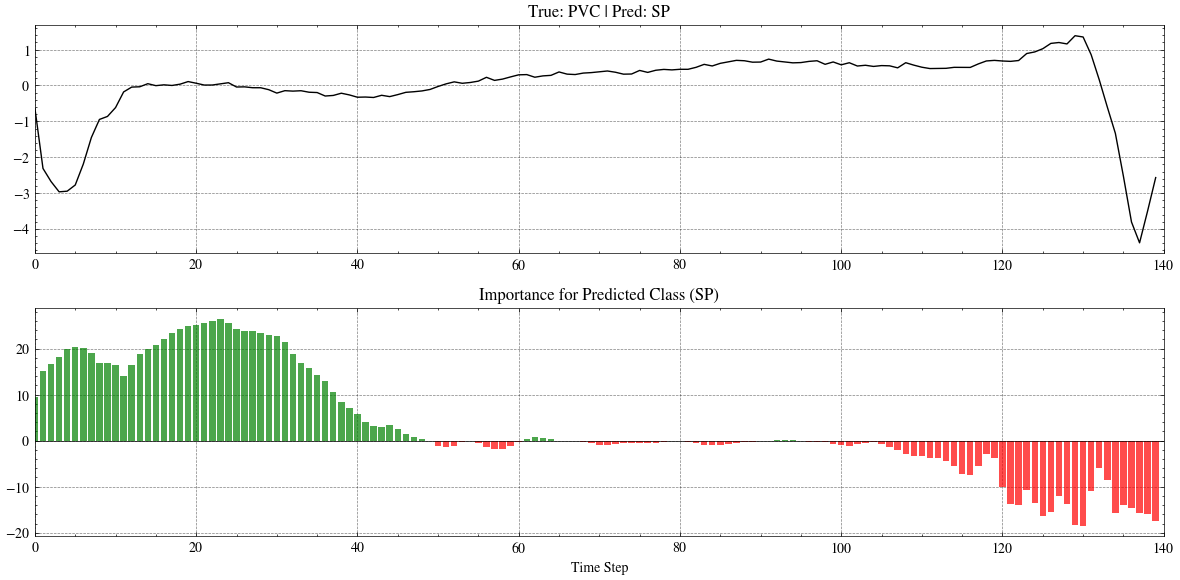

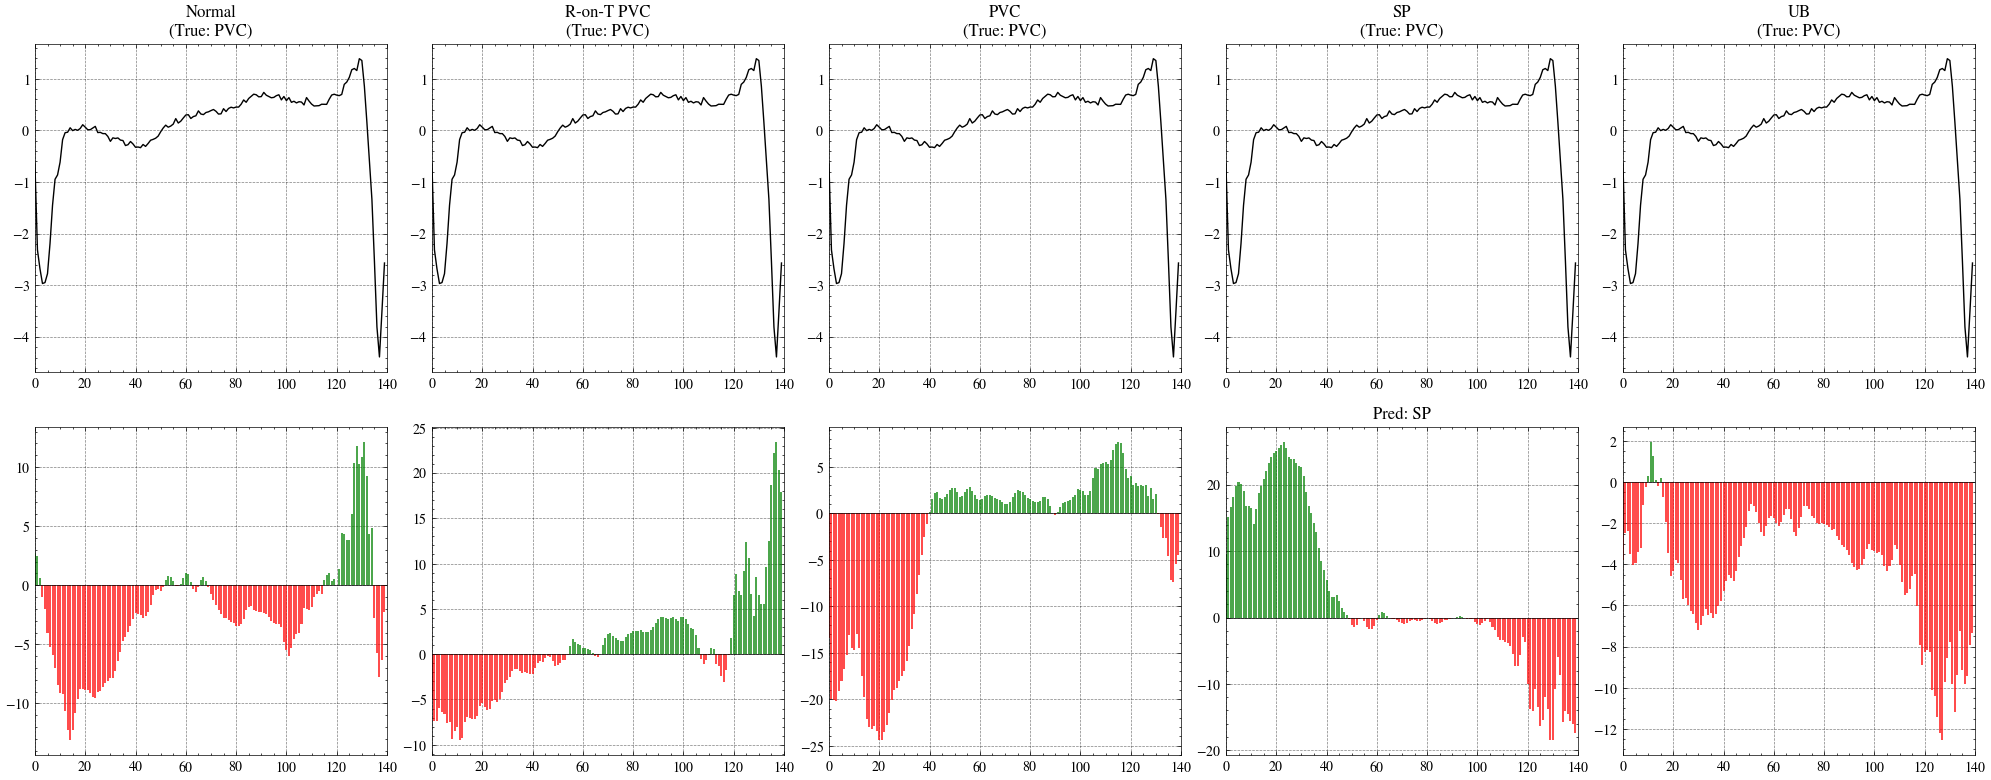

In [19]:
# CELL 14: Test on a minority class sample
minority_idx = test_dataset.get_samples_by_class(2, n_samples=1)[0]
print(f"Testing on minority class sample (Class 2 - PVC)")
interpret_sample(model, test_dataset, minority_idx, ECG5000_CLASS_NAMES)
compare_interpretations(model, test_dataset, minority_idx, ECG5000_CLASS_NAMES)

### Final notebook conclusion (simple)

This notebook shows the full ECG5000 flow and MILLET interpretation clearly.
Minority classes (PVC, SP, UB) are still challenging in this baseline setup.

Possible future improvements: stronger augmentation, focal loss, and better minority handling.
But for this notebook, the main target (interpretability demonstration) is achieved.

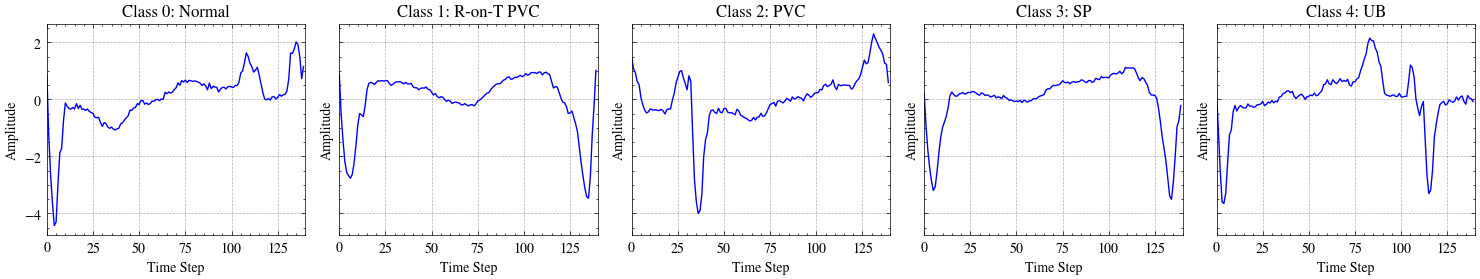

<Figure size 350x262.5 with 0 Axes>

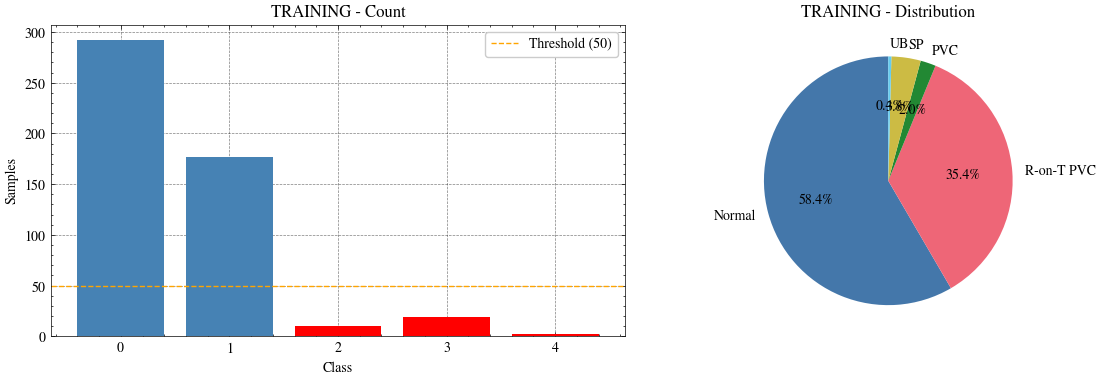

  Class 0:  292 samples - OK
  Class 1:  177 samples - OK
  Class 2:   10 samples - MINORITY
  Class 3:   19 samples - MINORITY
  Class 4:    2 samples - MINORITY


<Figure size 350x262.5 with 0 Axes>

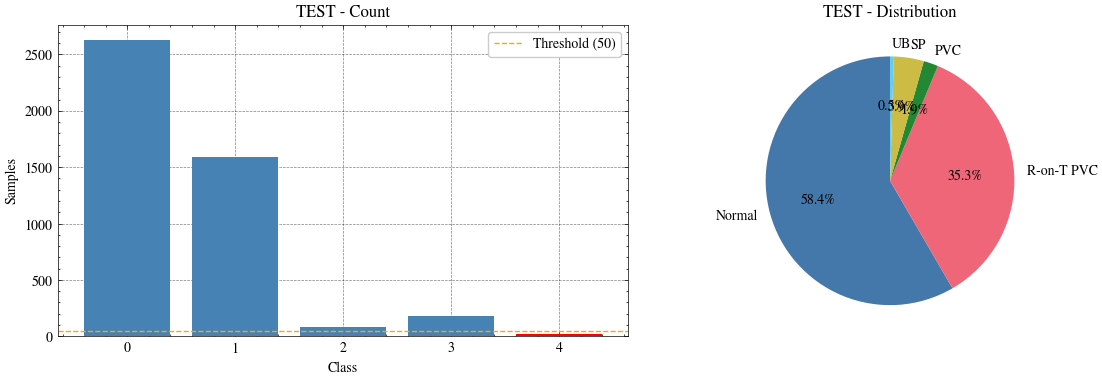

  Class 0: 2627 samples - OK
  Class 1: 1590 samples - OK
  Class 2:   86 samples - OK
  Class 3:  175 samples - OK
  Class 4:   22 samples - MINORITY


<Figure size 350x262.5 with 0 Axes>

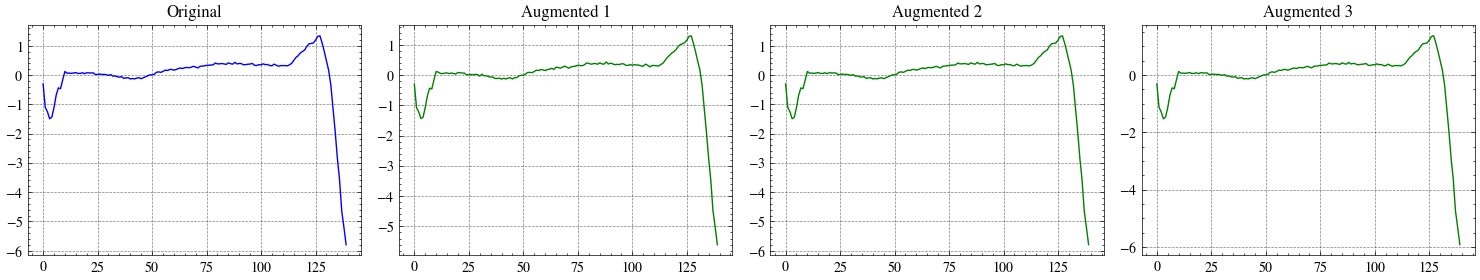

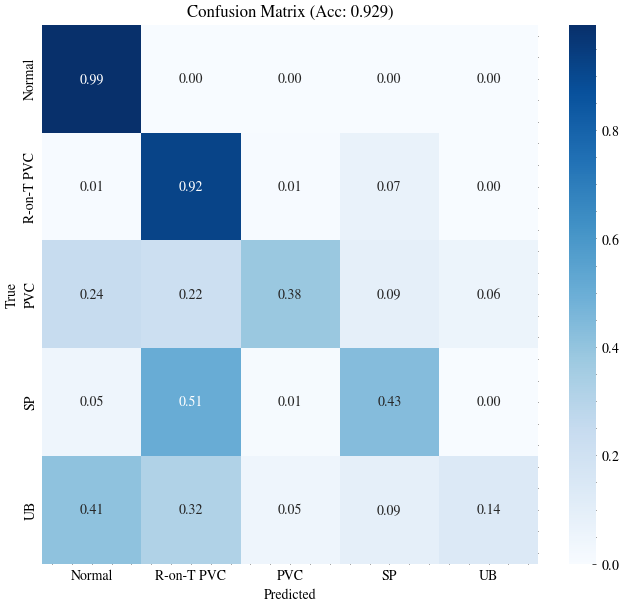

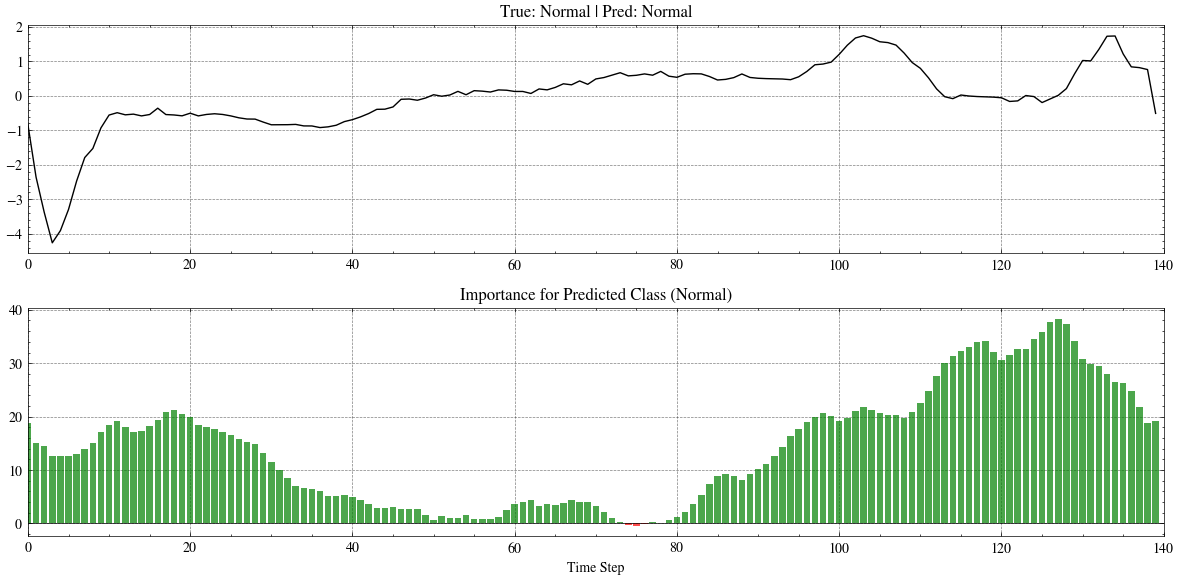

<Figure size 350x262.5 with 0 Axes>

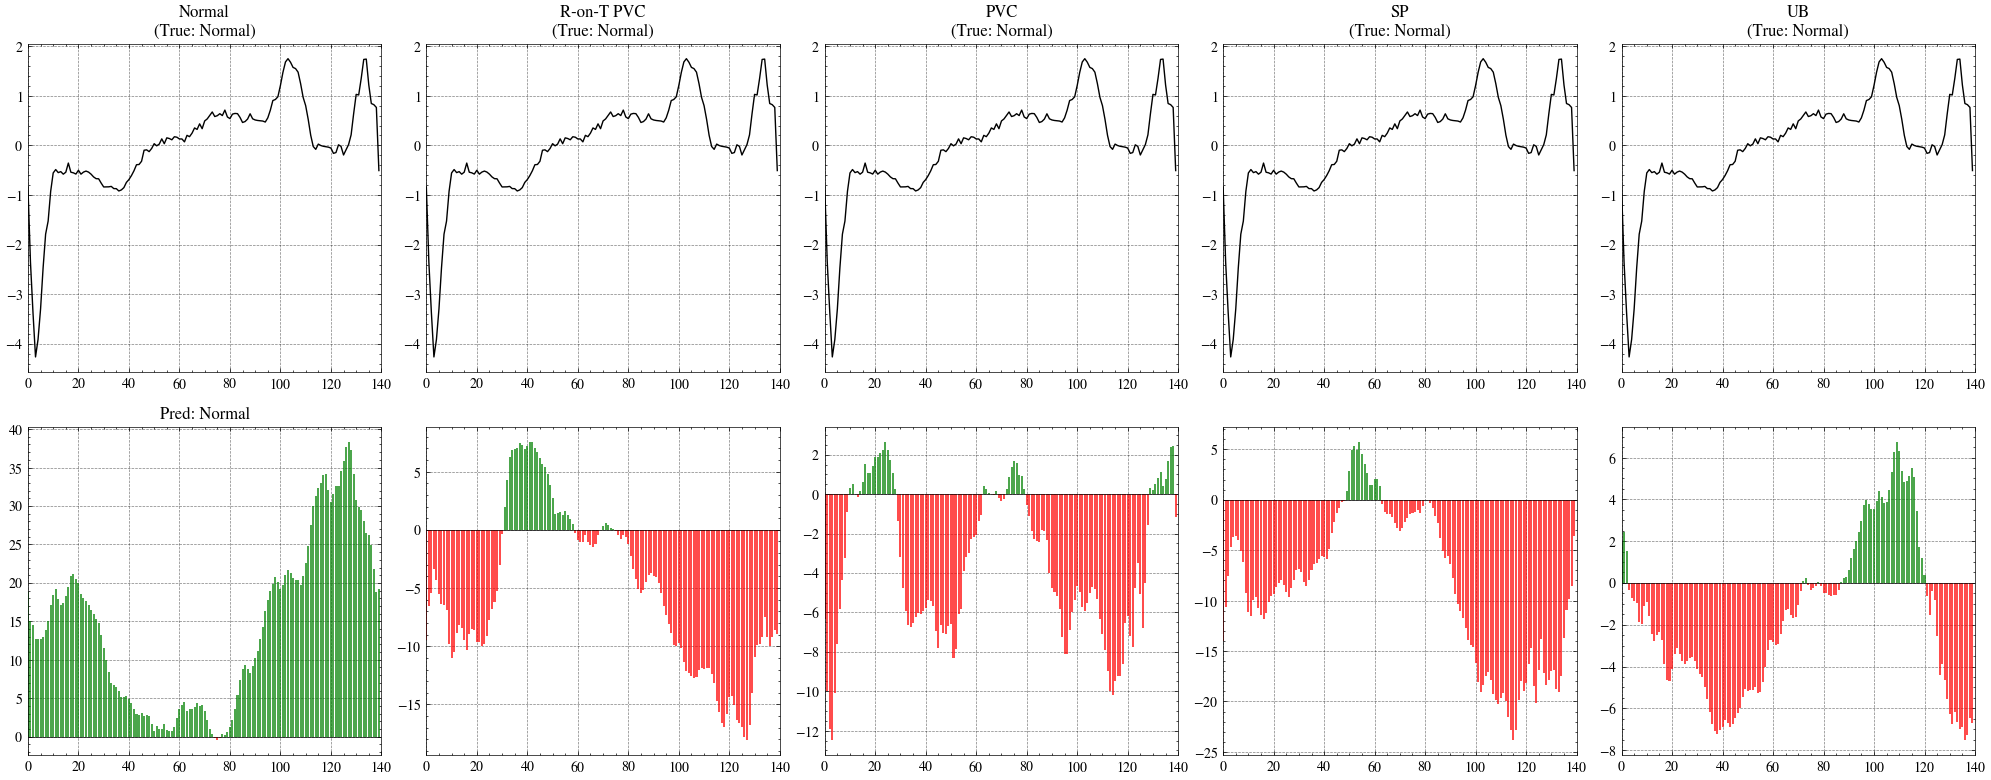

<Figure size 350x262.5 with 0 Axes>

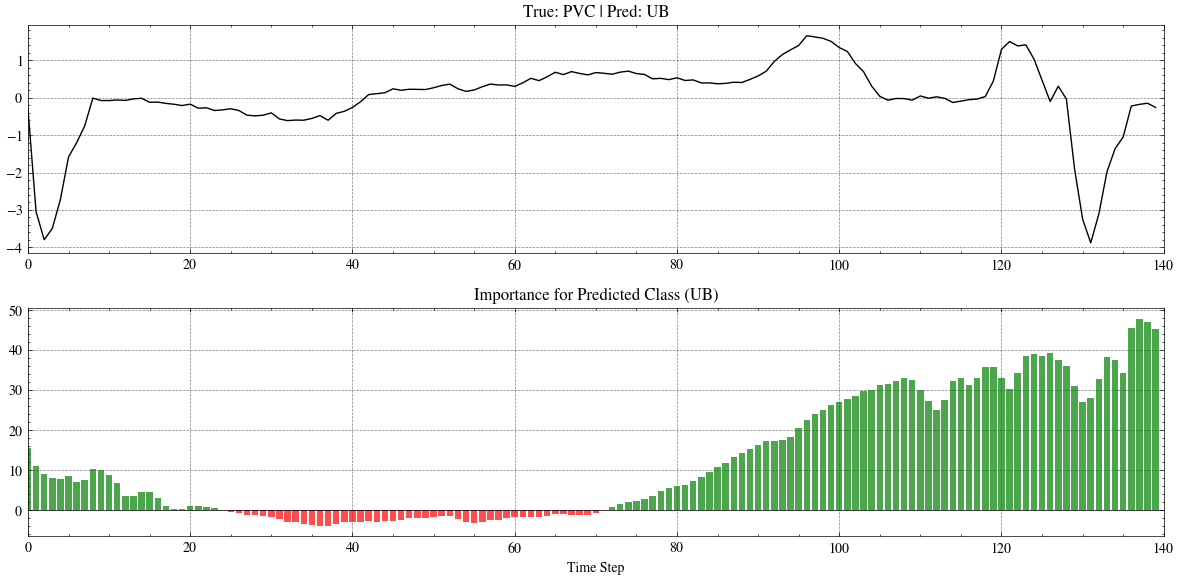

<Figure size 350x262.5 with 0 Axes>

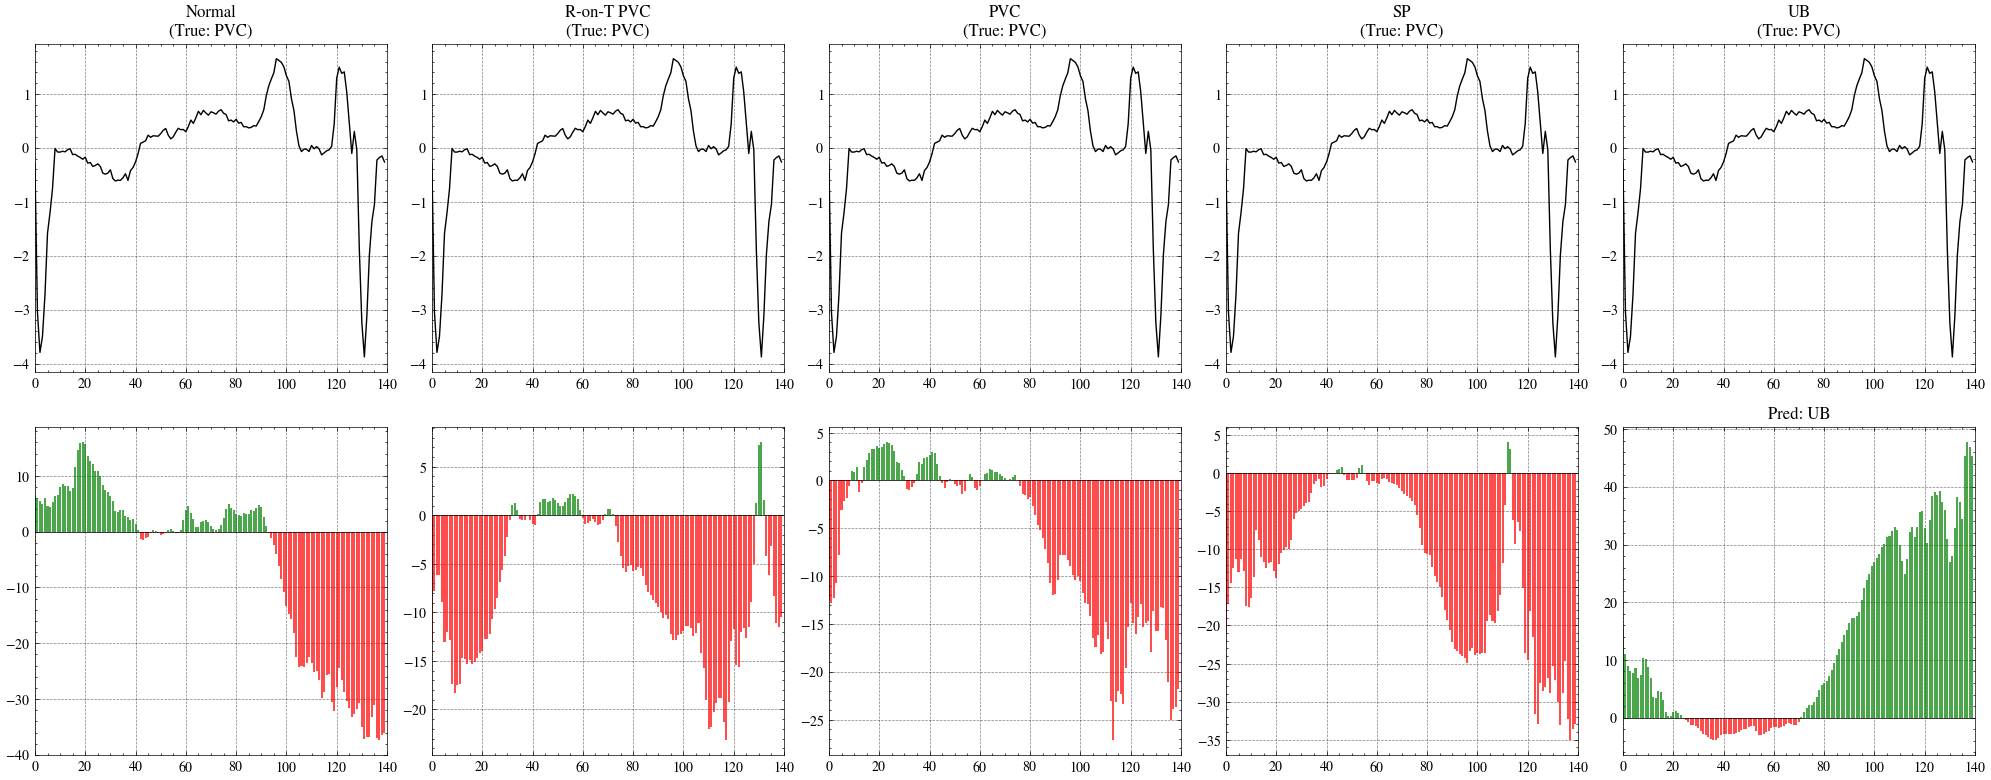

Saved plots to: D:\Documents\Intership TSC\millet_ecg\assets\ecg_plots


<Figure size 350x262.5 with 0 Axes>

In [20]:
# CELL 15: Export key plots for README
from pathlib import Path
from sklearn.metrics import confusion_matrix

out_dir = Path("assets/ecg_plots")
out_dir.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.gcf().savefig(out_dir / name, dpi=200, bbox_inches="tight")

# 1) One example per class
plot_class_examples(train_dataset, ECG5000_CLASS_NAMES)
save_fig("01_class_examples.png")

# 2) Class distributions (train + test)
show_distribution(train_dataset, ECG5000_CLASS_NAMES, "TRAINING")
save_fig("02_train_distribution.png")
show_distribution(test_dataset, ECG5000_CLASS_NAMES, "TEST")
save_fig("03_test_distribution.png")

# 3) Augmentation visualization
idx_aug = train_dataset.get_samples_by_class(2, n_samples=1)[0]
original = train_dataset.get_bag(idx_aug).squeeze().numpy()
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes[0].plot(original, 'b-')
axes[0].set_title("Original")
for i in range(1, 4):
    aug = augmenter.augment(torch.as_tensor(original).unsqueeze(1)).squeeze().numpy()
    axes[i].plot(aug, 'g-')
    axes[i].set_title(f"Augmented {i}")
plt.tight_layout()
save_fig("04_augmentation_example.png")
plt.show()

# 4) Confusion matrix
conf_mat = confusion_matrix(all_targets, all_preds)
conf_mat_norm = conf_mat.astype('float') / conf_mat.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    conf_mat_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=ECG5000_CLASS_NAMES,
    yticklabels=ECG5000_CLASS_NAMES
    )
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix (Acc: {acc:.3f})")
save_fig("05_confusion_matrix.png")
plt.show()

# 5) Interpretation plots
idx_interpret = test_dataset.get_samples_by_class(0, n_samples=1)[0]
interpret_sample(model, test_dataset, idx_interpret, ECG5000_CLASS_NAMES)
save_fig("06_single_sample_interpretation.png")

compare_interpretations(model, test_dataset, idx_interpret, ECG5000_CLASS_NAMES)
save_fig("07_compare_class_interpretations.png")

minority_idx_local = test_dataset.get_samples_by_class(2, n_samples=1)[0]
interpret_sample(model, test_dataset, minority_idx_local, ECG5000_CLASS_NAMES)
save_fig("08_minority_single_interpretation.png")
compare_interpretations(model, test_dataset, minority_idx_local, ECG5000_CLASS_NAMES)
save_fig("09_minority_compare_interpretations.png")

print(f"Saved plots to: {out_dir.resolve()}")